# SPAD ODMR Ensemble — Notebook README

> **Goal**: Load raw SPAD ODMR acquisitions saved as multi-part `.spc3` files, compute per-frequency averaged signal/reference images, apply optional background subtraction, and plot ODMR diagnostics. Exports processed arrays for downstream batch analysis.

---
## Configuration (edit these cells before running)

**Cell 3** — directory roots:
- `spad_dir`: root folder for SPAD data (contains `spc3/` and `processed/` subdirectories)
- `qm_dir`: root folder for the QM control software dataset

**Cell 4** — per-experiment settings:
- `spc3_file_header`: filename prefix of the continuous acquisition part-files (e.g. `spc3_continuous_20260518-135437-022759`). The notebook finds all files matching `<prefix><integer>.spc3` under `<spad_dir>/spc3/`.
- `qm_file`: path to the QM dataset folder relative to `qm_dir` (e.g. `Data\2026-05-18\#225_cw_odmr_101745`). Used to load the frequency axis and repetition count.
- `spad_background`: stem name of a single-frame background `.spc3` snapshot (e.g. `spc3_snap_20260518-093907-832450`), or `None` to skip background subtraction.

**Cell 5** — frequency axis toggle:
- `USE_LO_FREQUENCY`: set `True` to report absolute MW frequencies (LO + IF); set `False` to work in IF space only.

---
## Processing steps

1. **Load QM dataset** — extracts `f_vec` (frequency axis), `n_avg`, and `n_iteration` from the QM control software output.
2. **Discover SPC3 part-files** — finds all `<prefix><N>.spc3` files and sorts them by index.
3. **Read header** — extracts SPAD camera metadata from the first part-file; determines `integration_time_s` from gated (coarse gate stop − start) or ungated (SummedFrames × HwIntTime) settings.
4. **Load background** (if `spad_background` is set) — reads the single-frame background snapshot, computes `bg_avg_cps` (counts/sec/pixel averaged over all frames).
5. **Process all part-files** — streams through each file, accumulates complete repetitions only (each rep = 2 × F frames: signal then reference per frequency point), and builds `sig_avg_cps_bgsub` / `ref_avg_cps_bgsub`.
6. **Plot diagnostics** — reference image (with/without background subtraction) and full-array ODMR contrast spectrum.
7. **Export** (optional) — saves to `<spad_dir>/processed/`.

---
## What you get in memory
- `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`: arrays shaped `(F, n_rows, n_cols)` in counts/sec/pixel, background-subtracted if `spad_background` was set (otherwise equal to the raw averages).
- `f_vec`: frequency axis (Hz), either IF or LO+IF depending on `USE_LO_FREQUENCY`.
- `n_complete_reps`: number of complete repetitions included in the averages.
- `bg_avg_cps`: background image in counts/sec/pixel (or `None`).
- `header`: SPAD camera header metadata from the first SPC3 part-file.
- `integration_time_s`: gated or ungated exposure time used to convert raw counts → cps.

---
## Outputs written to disk (optional)
The **"export processed data"** cell saves to `<spad_dir>/processed/`:
- `<base_name>.npz` — compressed arrays (`sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`, `f_vec`, `n_complete_reps`, `bg_avg_cps`)
- `<base_name>_header.txt` — JSON metadata (QM dataset path, SPAD camera header, integration time, background file, array shapes)

## Next steps
- Feed the exported `.npz` file(s) into `SPAD_ODMR_batch.ipynb` for multi-experiment averaging and per-pixel signal visualization.

In [50]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re
from spc import SPC3

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))
from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter


In [51]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

In [52]:

spc3_file_header = 'spc3_continuous_20260523-185934-570694'
qm_file = r'Data/2026-05-23/#235_cw_odmr_181435'

#spad_background = None
spad_background = 'spc3_snap_20260523-170309-366731'             


In [53]:

# Toggle whether to use LO frequency (absolute MW freq) or just IF
USE_LO_FREQUENCY = False  # Set False to work in IF space

reader = DatasetReader(qm_dir)

qm_path = Path(qm_file)
qm_path = Path(qm_dir) / qm_path

ds_folder = reader.resolve_dataset(str(qm_path)).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

if_hz = np.asarray(data['IF_frequencies'], dtype=float)

cfg = data.get('config') or {}
if USE_LO_FREQUENCY:
    lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
    f_mw_hz = lo_hz + if_hz
else:
    lo_hz = None
    f_mw_hz = if_hz

f_vec = f_mw_hz

n_avg = int(data.get('n_avg', 1))
# 'iteration' is 0-indexed:
# Falls back to n_avg when the field is absent
n_iteration = int(data.get('iteration', n_avg - 1)) + 1

print(f'Loaded: {ds.folder}')
print(f"n_avg        : {n_avg}  (requested)")
print(f"n_iteration  : {n_iteration}  (actually completed)")
if n_iteration != n_avg:
    print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
print(f"len(f_vec)   : {len(f_vec)}")
print(f"f_vec range  : {f_vec.min()/1e6:.1f} – {f_vec.max()/1e6:.1f} MHz")
print(f"Expected total frames: {2 * n_iteration * len(f_vec)}") #sig,ref frames per iteration, per frequency point


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-05-23\#235_cw_odmr_181435
n_avg        : 500000  (requested)
n_iteration  : 500000  (actually completed)
len(f_vec)   : 60
f_vec range  : 50.0 – 109.0 MHz
Expected total frames: 60000000


In [54]:

spad_dir_path = Path(spad_dir)
spc3_path = spad_dir_path / 'spc3'

# Discover all part-files saved as
#   <prefix><index>.spc3  where <index> is an integer (1,2,...,10,11,...)
_prefix = re.sub(r'\d+$', '', str(spc3_file_header))
_part_re = re.compile(r'^' + re.escape(_prefix) + r'(\d+)\.spc3$', re.IGNORECASE)

def _spc3_sort_key(p: Path) -> int:
    m = _part_re.match(p.name)
    return int(m.group(1)) if m else -1

spc3_files = sorted(
    (p for p in spc3_path.glob(f'{_prefix}*.spc3') if _part_re.match(p.name)),
    key=_spc3_sort_key
)

if not spc3_files:
    raise FileNotFoundError(
        f"No SPC3 files found matching '{_prefix}<integer>.spc3' in\n  {spc3_path}"
    )

print(f"Found {len(spc3_files)} SPC3 file(s):")
for fp in spc3_files:
    print(f"  {fp.name}")

Found 58 SPC3 file(s):
  spc3_continuous_20260523-185934-570694.spc3
  spc3_continuous_20260523-185934-5706942.spc3
  spc3_continuous_20260523-185934-5706943.spc3
  spc3_continuous_20260523-185934-5706944.spc3
  spc3_continuous_20260523-185934-5706945.spc3
  spc3_continuous_20260523-185934-5706946.spc3
  spc3_continuous_20260523-185934-5706947.spc3
  spc3_continuous_20260523-185934-5706948.spc3
  spc3_continuous_20260523-185934-5706949.spc3
  spc3_continuous_20260523-185934-57069410.spc3
  spc3_continuous_20260523-185934-57069411.spc3
  spc3_continuous_20260523-185934-57069412.spc3
  spc3_continuous_20260523-185934-57069413.spc3
  spc3_continuous_20260523-185934-57069414.spc3
  spc3_continuous_20260523-185934-57069415.spc3
  spc3_continuous_20260523-185934-57069416.spc3
  spc3_continuous_20260523-185934-57069417.spc3
  spc3_continuous_20260523-185934-57069418.spc3
  spc3_continuous_20260523-185934-57069419.spc3
  spc3_continuous_20260523-185934-57069420.spc3
  spc3_continuous_20260523-

In [55]:

# extract metadata from first file
frames, header = SPC3.ReadSPC3DataFile(spc3_files[0])

# frames shape: (n_counters, n_frames, n_cols, n_rows)
print("=== Header (first file) ===")
#print(f"  camera_id    : {header.camera_id}")
#print(f"  serial       : {header.SN}")
#print(f"  firmware ver : {header.FW_VER}")
print(f"  n_frames     : {header.N_frames}")
print(f"  n_counters   : {header.N_counters}")
print(f"  n_rows       : {header.N_rows}")
print(f"  n_cols       : {header.N_cols}")
print(f"  bits/pixel   : {header.bit_x_pix}")
print(f"  n_pixels     : {header.N_pix}")
print(f"  HW integ time: {header.HwIntTime * 1e6:.3f} µs")
print(f"  summed frames: {header.SummedFrames}")
print(f"  coarse gate C1: {header.CoarseGate_C1_ON}  ")
if header.CoarseGate_C1_ON:
    integration_time_s = header.CoarseGate_C1_stopPos - header.CoarseGate_C1_startPos
    print(f"  gated integration time = {integration_time_s * 1e9:.3f} ns")
else:
    integration_time_s = header.SummedFrames * header.HwIntTime
    print(f"  ungated exposure time : {header.SummedFrames * header.HwIntTime * 1e6:.3f} µs")
    print("  WARNING: CoarseGate_C1_ON is False. If gating was active, the header was not")
    print("  correctly stamped. Run the fallback cell below to set integration_time_s manually.")

print(f"\n=== Frames (first file) ===")
print(f"  shape : {frames.shape}  (n_counters, n_frames, n_cols, n_rows)")
print(f"  dtype : {frames.dtype}")
print(f"  min/max (counter 0): {frames[0].min()}, {frames[0].max()}")


=== Header (first file) ===
  n_frames     : 1048574
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 8
  n_pixels     : 1024
  HW integ time: 10.400 µs
  summed frames: 1
  coarse gate C1: True  
  gated integration time = 7400.000 ns

=== Frames (first file) ===
  shape : (1, 1048574, 32, 32)  (n_counters, n_frames, n_cols, n_rows)
  dtype : uint8
  min/max (counter 0): 0, 7


=== Header ===
  n_frames     : 50
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 16
  n_pixels     : 1024
  HW integ time: 52.000 µs
  summed frames: 2000
  coarse gate C1: False
  ungated exposure time : 104000.000 µs

=== Frames ===
  shape : (50, 32, 32)  (n_frames, n_rows, n_cols)
  dtype : uint16
  min/max: 2, 6237


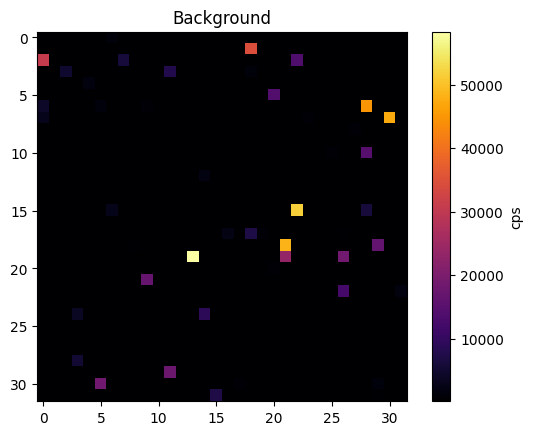

In [56]:

bg_path = spc3_path / f'{spad_background}.spc3'
_, header_bg = SPC3.ReadSPC3DataFile(str(bg_path))   # header only

print("=== Header ===")
print(f"  n_frames     : {header_bg.N_frames}")
print(f"  n_counters   : {header_bg.N_counters}")
print(f"  n_rows       : {header_bg.N_rows}")
print(f"  n_cols       : {header_bg.N_cols}")
print(f"  bits/pixel   : {header_bg.bit_x_pix}")
print(f"  n_pixels     : {header_bg.N_pix}")
print(f"  HW integ time: {header_bg.HwIntTime * 1e6:.3f} µs")
print(f"  summed frames: {header_bg.SummedFrames}")
print(f"  coarse gate C1: {header_bg.CoarseGate_C1_ON}")
if header_bg.CoarseGate_C1_ON:
    integration_time_s_bg = header_bg.CoarseGate_C1_stopPos - header_bg.CoarseGate_C1_startPos
    print(f"  gated integration time = {integration_time_s_bg * 1e9:.3f} ns")
else:
    integration_time_s_bg = header_bg.SummedFrames * header_bg.HwIntTime
    print(f"  ungated exposure time : {integration_time_s_bg * 1e6:.3f} µs")

dtype_bg = np.uint8 if header_bg.bit_x_pix == 8 else np.uint16
n_rows_bg, n_cols_bg = header_bg.N_rows, header_bg.N_cols

raw_bg = np.memmap(str(bg_path), dtype=dtype_bg, mode='r', offset=1032)
n_frames_bg = raw_bg.size // (n_rows_bg * n_cols_bg)
frames_bg_arr = raw_bg[:n_frames_bg * n_rows_bg * n_cols_bg].reshape(n_frames_bg, n_rows_bg, n_cols_bg)

print(f"\n=== Frames ===")
print(f"  shape : {frames_bg_arr.shape}  (n_frames, n_rows, n_cols)")
print(f"  dtype : {frames_bg_arr.dtype}")
print(f"  min/max: {frames_bg_arr.min()}, {frames_bg_arr.max()}")

bg_avg_cps = frames_bg_arr.mean(axis=0).astype(np.float64) / integration_time_s_bg

del raw_bg, frames_bg_arr

plt.imshow(bg_avg_cps, cmap='inferno')
plt.colorbar(label='cps')
plt.title('Background')
plt.show()

In [57]:

# load all data files
# Uses np.memmap so each file is paged in by the OS on demand rather than read
# into RAM all at once, and sums directly in float64 to avoid an 8x memory copy.

DATA_OFFSET = 1032   # bytes: 1024-byte SPC3 header + 8-byte file meta

n_rows = header.N_rows
n_cols = header.N_cols
dtype  = np.uint8 if header.bit_x_pix == 8 else np.uint16

F = len(f_mw_hz)
frames_per_rep = 2 * F

sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
n_complete_reps = 0
carry = None          # small in-RAM array of leftover frames from previous file
N_frames_raw = 0

for fp in spc3_files:
    raw = np.memmap(str(fp), dtype=dtype, mode='r', offset=DATA_OFFSET)
    n_frames_file = raw.size // (n_rows * n_cols)
    frames = raw[:n_frames_file * n_rows * n_cols].reshape(n_frames_file, n_rows, n_cols)
    N_frames_raw += n_frames_file

    # --- handle carry from previous file --------------------------------
    if carry is not None and carry.shape[0] > 0:
        gap = frames_per_rep - (carry.shape[0] % frames_per_rep)
        if gap < frames_per_rep and gap <= n_frames_file:
            # complete the partial rep with the first 'gap' frames of this file
            combined = np.concatenate([carry, np.array(frames[:gap])], axis=0)
            n_reps_combined = combined.shape[0] // frames_per_rep
            if n_reps_combined > 0:
                rv = combined[:n_reps_combined * frames_per_rep].reshape(n_reps_combined, F, 2, n_rows, n_cols)
                sig_sum += rv[:, :, 0, :, :].sum(axis=0, dtype=np.float64)
                ref_sum += rv[:, :, 1, :, :].sum(axis=0, dtype=np.float64)
                n_complete_reps += n_reps_combined
            start_idx = gap
        else:
            carry = np.concatenate([carry, np.array(frames)], axis=0)
            continue
        carry = None
    else:
        start_idx = 0

    # --- process the bulk of this file via zero-copy memmap view --------
    n_remaining = n_frames_file - start_idx
    n_complete_here = (n_remaining // frames_per_rep) * frames_per_rep

    if n_complete_here > 0:
        batch = frames[start_idx : start_idx + n_complete_here]   # zero-copy view
        rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)        # zero-copy view
        sig_sum += rep_view[:, :, 0, :, :].sum(axis=0, dtype=np.float64)
        ref_sum += rep_view[:, :, 1, :, :].sum(axis=0, dtype=np.float64)
        n_complete_reps += n_complete_here // frames_per_rep

    leftover_start = start_idx + n_complete_here
    if leftover_start < n_frames_file:
        carry = np.array(frames[leftover_start:])   # copy to RAM — always < frames_per_rep frames

    del raw, frames   # release memmap; OS can evict pages

    print(f"  {fp.name}: {n_complete_here} frames used  "
          f"(running total: {n_complete_reps} complete reps)")

dropped = N_frames_raw - n_complete_reps * frames_per_rep
print(f"\nTotal frames raw     : {N_frames_raw}")
print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
if dropped:
    print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")

sig_avg = sig_sum / n_complete_reps
ref_avg = ref_sum / n_complete_reps

sig_avg_cps = sig_avg / integration_time_s
ref_avg_cps = ref_avg / integration_time_s

if spad_background is not None:
    sig_avg_cps_bgsub = sig_avg_cps - bg_avg_cps
    ref_avg_cps_bgsub = ref_avg_cps - bg_avg_cps
else:
    sig_avg_cps_bgsub = sig_avg_cps
    ref_avg_cps_bgsub = ref_avg_cps

print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")

  spc3_continuous_20260523-185934-570694.spc3: 1048560 frames used  (running total: 8738 complete reps)
  spc3_continuous_20260523-185934-5706942.spc3: 1048440 frames used  (running total: 17476 complete reps)
  spc3_continuous_20260523-185934-5706943.spc3: 1048440 frames used  (running total: 26214 complete reps)
  spc3_continuous_20260523-185934-5706944.spc3: 1048440 frames used  (running total: 34952 complete reps)
  spc3_continuous_20260523-185934-5706945.spc3: 1048440 frames used  (running total: 43690 complete reps)
  spc3_continuous_20260523-185934-5706946.spc3: 1048440 frames used  (running total: 52428 complete reps)
  spc3_continuous_20260523-185934-5706947.spc3: 1048440 frames used  (running total: 61166 complete reps)
  spc3_continuous_20260523-185934-5706948.spc3: 1048440 frames used  (running total: 69904 complete reps)
  spc3_continuous_20260523-185934-5706949.spc3: 1048560 frames used  (running total: 78643 complete reps)
  spc3_continuous_20260523-185934-57069410.spc3:

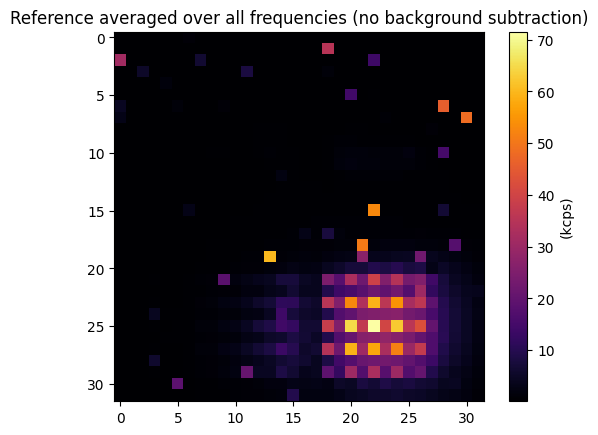

In [58]:
plt.imshow(1e-3*ref_avg_cps.mean(axis =0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all frequencies (no background subtraction)')
plt.show()


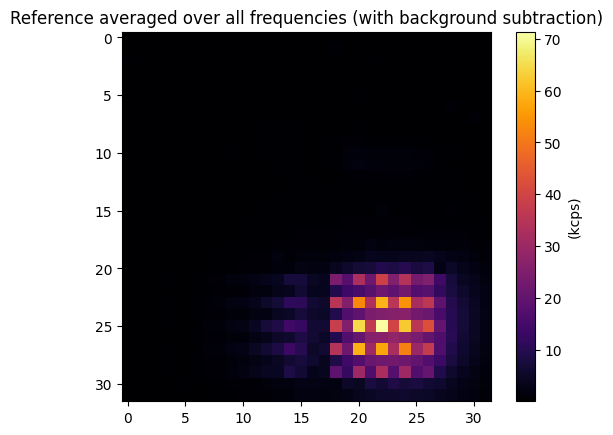

In [59]:
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis =0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all frequencies (with background subtraction)')
plt.show()


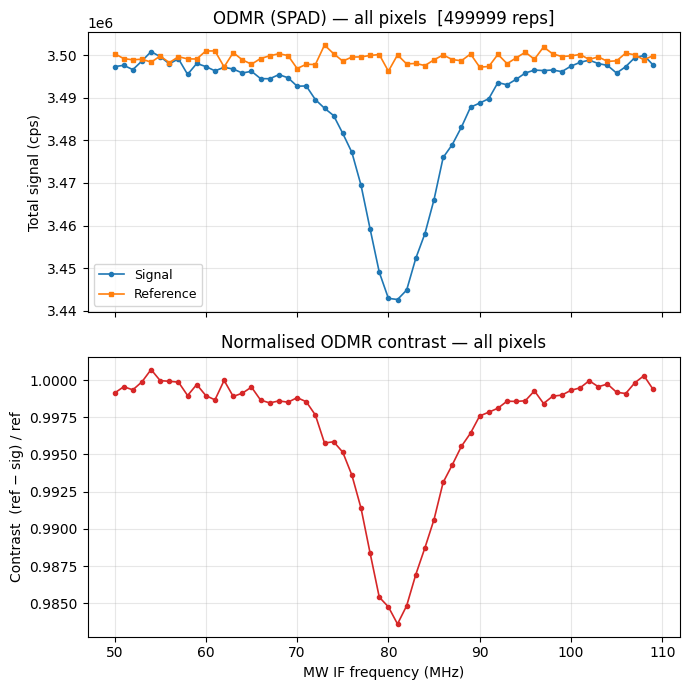

In [60]:
f_mhz = f_mw_hz / 1e6

sig_counts  = sig_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(f_mhz, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total signal (cps)')
axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast — all pixels')
axes[1].grid(True, alpha=0.3)
#axes[1].set_ylim([0.96, 1.01])

plt.tight_layout()
plt.show()

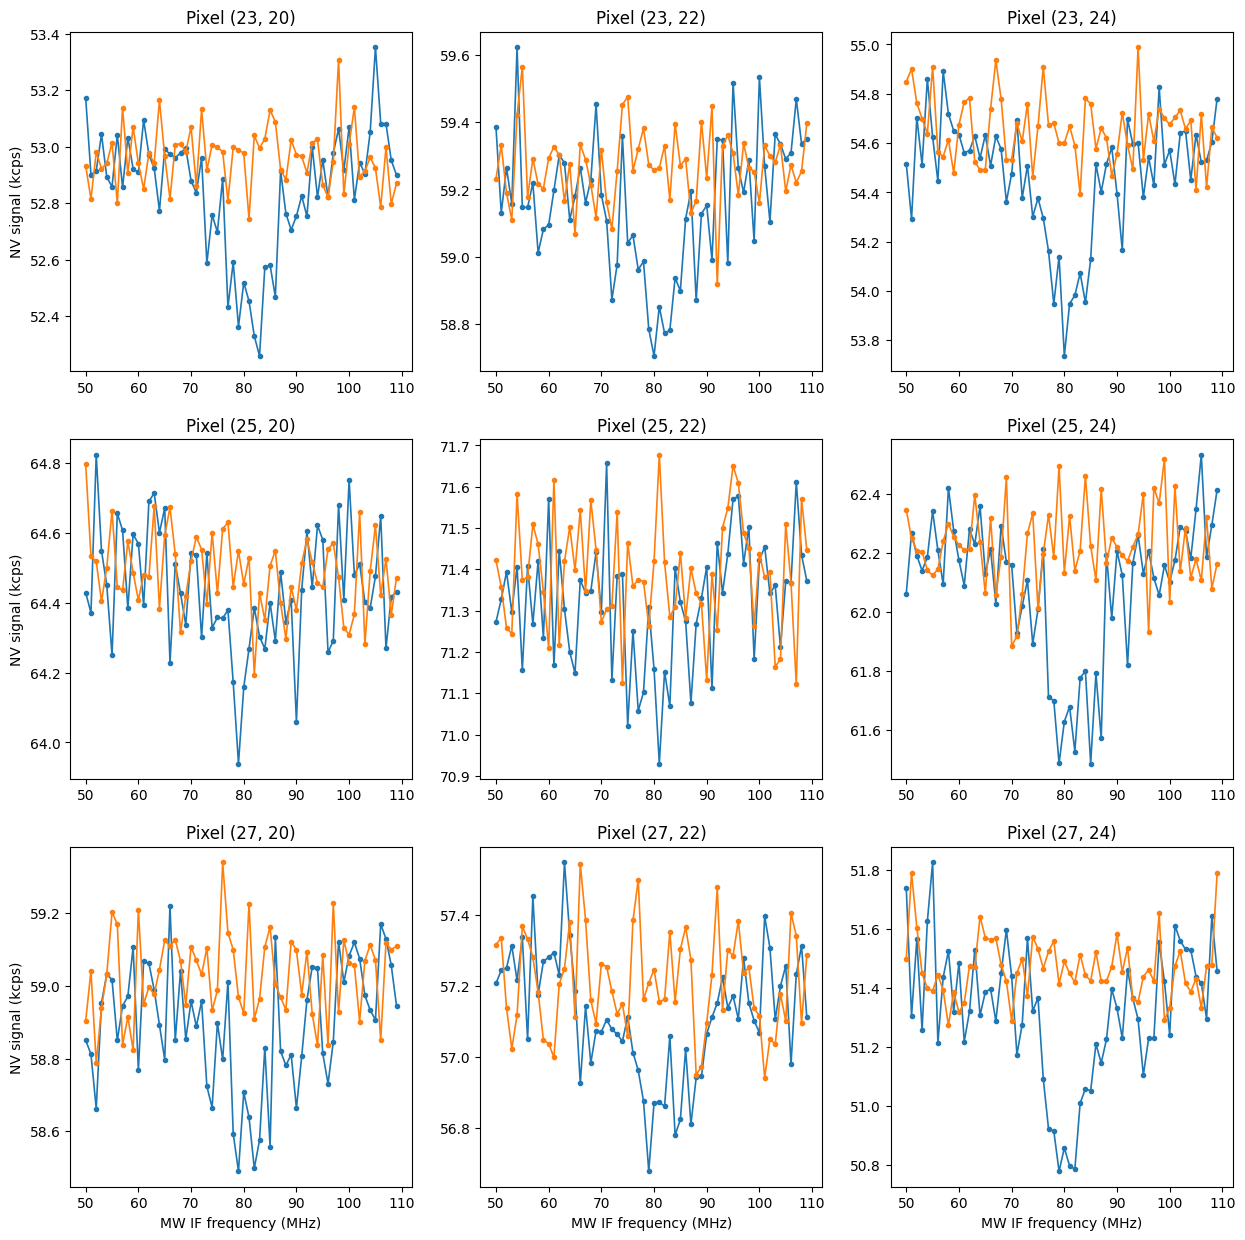

In [61]:
#plot signal and ref for each pixel in 3X3 emitter array centered at brightest pixel

f_mhz = f_vec / 1e6

#find brightest pixel in ref_avg.mean and set as array centre
ref_frame = ref_avg_cps_bgsub.mean(axis =0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
#print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    for j in range(3):

        sig_pix = (sig_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
        ref_pix = (ref_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])

        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(f_mhz, sig_pix/1000, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref_pix/1000, 'o-', ms=3, lw=1.2, label='Reference')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        #plt.ylim(0.94,1.02)
        if i==2:
            plt.xlabel('MW IF frequency (MHz)')
        if j==0:
            plt.ylabel('NV signal (kcps)')


In [62]:

#export processed data 

# Save processed/averaged bg-subtracted arrays + metadata
out_dir = Path(spad_dir) / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

dataset_tag = re.sub(r'[^A-Za-z0-9_.-]+', '_', Path(qm_file).name)
base_name = f"{spc3_file_header}_{dataset_tag}_avg"
array_path = out_dir / f"{base_name}.npz"
meta_path = out_dir / f"{base_name}_header.txt"


def _to_builtin(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(k): _to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_to_builtin(v) for v in value]
    try:
        json.dumps(value)
        return value
    except (TypeError, OverflowError):
        return str(value)

def _obj_to_dict(obj):
    try:
        raw = vars(obj)
        if raw:
            return {k: _to_builtin(v) for k, v in raw.items()}
    except TypeError:
        pass

    out = {}
    for name in dir(obj):
        if name.startswith('_'):
            continue
        try:
            val = getattr(obj, name)
        except Exception:
            continue
        if callable(val):
            continue
        out[name] = _to_builtin(val)
    return out

# Save data arrays in compressed form (all are shape (F, n_rows, n_cols) except f_vec)
np.savez_compressed(
    array_path,
    sig_avg_cps_bgsub=sig_avg_cps_bgsub,
    ref_avg_cps_bgsub=ref_avg_cps_bgsub,
    f_vec=f_vec,
    n_complete_reps=n_complete_reps,
    bg_avg_cps=bg_avg_cps if spad_background is not None else None,
    bg_filename=str(spad_dir_path / f'{spad_background}.spc3') if spad_background is not None else None,
)

metadata_export = {
    'export': {
        'array_file': str(array_path),
        'array_shapes': {
            'sig_avg_cps_bgsub': list(sig_avg_cps_bgsub.shape),
            'ref_avg_cps_bgsub': list(ref_avg_cps_bgsub.shape),
            'f_vec': list(np.shape(f_vec)),
            'bg_avg_cps': list(np.shape(bg_avg_cps)) if spad_background is not None else None,
        },
    },
    'run_info': {
        'qm_file': str(ds.folder),
        'n_complete_reps': int(n_complete_reps),
    },
    'spc3_data': {
        #'spc3 file 0': str(spad_dir_path / f'{spc3_files[0]}'),
        'spad measurement metadata': _obj_to_dict(header),
        'integration_time_s': integration_time_s,
        #'background file': str(spad_dir_path / f'{spad_background}.spc3') if spad_background is not None else None,
        'spad background metadata': _obj_to_dict(header_bg) if spad_background is not None else None,
    },
}

with open(meta_path, 'w', encoding='utf-8') as f:
    f.write('SPAD ODMR processed export metadata\n')
    f.write('=' * 36 + '\n\n')
    f.write(json.dumps(metadata_export, indent=2))

print(f'Saved arrays   -> {array_path}')
print(f'Saved metadata -> {meta_path}')

Saved arrays   -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260523-185934-570694__235_cw_odmr_181435_avg.npz
Saved metadata -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260523-185934-570694__235_cw_odmr_181435_avg_header.txt
